<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part I · Foundations &nbsp;|&nbsp; Chapter 6</div>
  <div style="font-size:38px;font-weight:900;line-height:1.1;margin:10px 0 6px">Population vs. Sample <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:710px;line-height:1.6">Four demos on the heartbeat of statistics: a sample statistic estimates a population parameter. We compute both, watch statistics vary, see them sharpen with more data, and run a mini opinion poll.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

> ### 🎯 What you'll build in this notebook
>
> | # | Demo | Concept |
> |---|------|---------|
> | 1 | Compute parameters, then statistics | **Parameter (μ, σ, p) vs statistic (x̄, s, p̂)** |
> | 2 | Take many samples | **Sampling variability** — statistics jiggle around the parameter |
> | 3 | Grow the sample | **Bigger n → better estimate** |
> | 4 | Run an opinion poll | **Census vs sampling** + margin of error |

---

## ⚙️ Setup — imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(6)

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"
GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
    "axes.edgecolor":GRID,"axes.linewidth":1.2,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,
    "axes.spines.top":False,"axes.spines.right":False,"axes.titlesize":15,"axes.titleweight":"bold","axes.titlecolor":INK,
    "axes.labelcolor":INK_SOFT,"axes.labelsize":11.5,"xtick.color":INK_SOFT,"ytick.color":INK_SOFT,"legend.frameon":False,
})
def titlecard(ax, title, subtitle=None):
    ax.set_title(title, loc="left", pad=18)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=10.5, color=INK_SOFT, va="bottom")
print("✅ Environment ready.")

✅ Environment ready.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · PARAMETER vs STATISTIC</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🌍 The whole vs. a slice</div>
<div style="color:#4a5578;margin-top:6px">A parameter describes the whole population (μ, σ, p). A statistic describes a sample (x̄, s, p̂). We almost never know the parameter — so we estimate it with a statistic.</div>
</div>

In [2]:
# Pretend we COULD measure everyone: a population of 50,000 adult heights (cm)
population = rng.normal(170, 10, 50_000)

# PARAMETERS (truth about the whole population — usually unknown in real life)
mu    = population.mean()                 # μ  population mean
sigma = population.std()                  # σ  population standard deviation
p     = np.mean(population > 180)          # p  proportion taller than 180 cm

# Take ONE random sample of 50 people and compute STATISTICS
sample = rng.choice(population, size=50, replace=False)
xbar   = sample.mean()                    # x̄  sample mean
s      = sample.std(ddof=1)               # s   sample standard deviation
phat   = np.mean(sample > 180)             # p̂  sample proportion

print(pd.DataFrame({
    "quantity":     ["mean", "std dev", "proportion > 180cm"],
    "PARAMETER (pop)":[f"μ = {mu:.1f}", f"σ = {sigma:.1f}", f"p = {p:.2f}"],
    "STATISTIC (n=50)":[f"x̄ = {xbar:.1f}", f"s = {s:.1f}", f"p̂ = {phat:.2f}"],
}).to_string(index=False))

          quantity PARAMETER (pop) STATISTIC (n=50)
              mean       μ = 170.0       x̄ = 166.9
           std dev        σ = 10.0          s = 9.9
proportion > 180cm        p = 0.16        p̂ = 0.08


Notice the statistics (from just 50 people) land **close to** the parameters (from all 50,000) — but not exactly. That gap is the whole subject of inferential statistics.

<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · SAMPLING VARIABILITY</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🎲 Every sample tells a slightly different story</div>
<div style="color:#4a5578;margin-top:6px">Take a new sample and the statistic changes. But those statistics cluster tightly around the true parameter.</div>
</div>

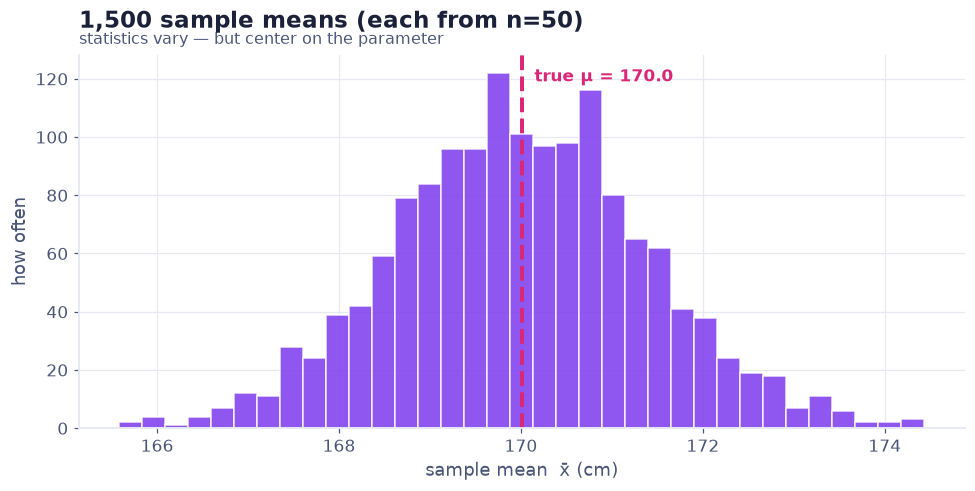

Average of all the sample means: 170.01  (≈ μ = 170.02)
Spread of the sample means     : 1.40 cm  (the standard error)


In [3]:
sample_means = np.array([rng.choice(population, 50, replace=False).mean() for _ in range(1500)])

fig, ax = plt.subplots(figsize=(9,4.6))
ax.hist(sample_means, bins=35, color=PURPLE, alpha=0.85, edgecolor="white")
ax.axvline(mu, color=PINK, lw=2.6, ls="--")
ax.text(mu, ax.get_ylim()[1]*0.93, f"  true μ = {mu:.1f}", color=PINK, fontweight="bold")
titlecard(ax, "1,500 sample means (each from n=50)", "statistics vary — but center on the parameter")
ax.set_xlabel("sample mean  x̄ (cm)"); ax.set_ylabel("how often")
plt.tight_layout(); plt.show()

print(f"Average of all the sample means: {sample_means.mean():.2f}  (≈ μ = {mu:.2f})")
print(f"Spread of the sample means     : {sample_means.std():.2f} cm  (the standard error)")

Each x̄ is a little off, but they're **unbiased**: on average they hit μ exactly. The spread of these estimates is called the **standard error**.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · BIGGER SAMPLE, BETTER ESTIMATE</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📉 Error shrinks as n grows</div>
<div style="color:#4a5578;margin-top:6px">Larger samples give statistics that hug the parameter more tightly. Doubling accuracy costs more than double the data, though.</div>
</div>

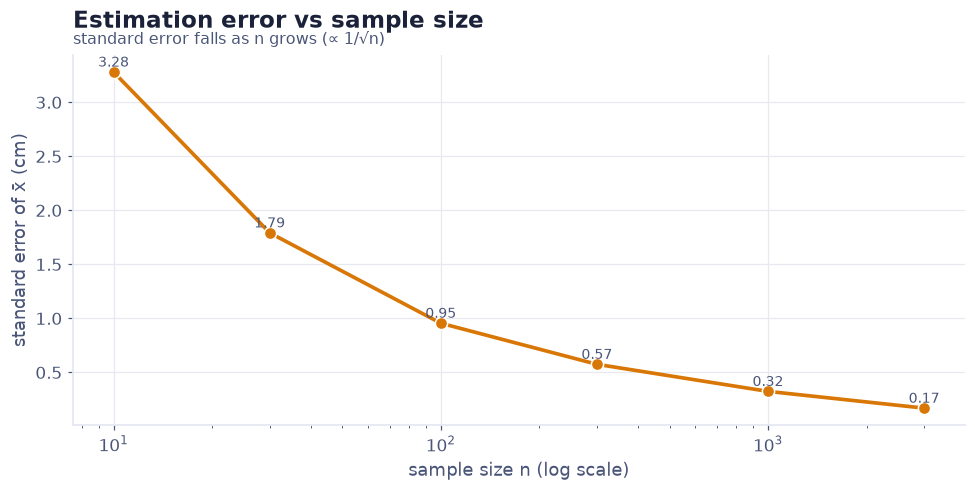

Rule of thumb: to halve the error you need ~4× the sample (error ∝ 1/√n).


In [4]:
sizes = [10, 30, 100, 300, 1000, 3000]
errors = []
for n in sizes:
    means = np.array([rng.choice(population, n, replace=False).mean() for _ in range(400)])
    errors.append(means.std())   # typical distance of x̄ from μ

fig, ax = plt.subplots(figsize=(9,4.6))
ax.plot(sizes, errors, "o-", color=AMBER, lw=2.4, markersize=8, markeredgecolor="white")
for n, e in zip(sizes, errors):
    ax.text(n, e+0.05, f"{e:.2f}", ha="center", fontsize=9, color=INK_SOFT)
titlecard(ax, "Estimation error vs sample size", "standard error falls as n grows (∝ 1/√n)")
ax.set_xscale("log"); ax.set_xlabel("sample size n (log scale)"); ax.set_ylabel("standard error of x̄ (cm)")
plt.tight_layout(); plt.show()

print("Rule of thumb: to halve the error you need ~4× the sample (error ∝ 1/√n).")

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 4 · CENSUS vs SAMPLING</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🗳️ Why a poll of 1,000 can speak for millions</div>
<div style="color:#4a5578;margin-top:6px">A census measures everyone (the parameter exactly) but is slow and costly. A sample estimates it cheaply, with a known margin of error.</div>
</div>

In [5]:
# A population of 2,000,000 voters; the TRUE support (parameter) p:
true_support = 0.54
voters = rng.random(2_000_000) < true_support
p_param = voters.mean()

# A "census" would poll all 2,000,000. Instead we poll a SAMPLE of 1,000.
poll = rng.choice(voters, size=1000, replace=False)
phat = poll.mean()
moe  = 1.96 * np.sqrt(phat*(1-phat)/1000)   # 95% margin of error

print(f"CENSUS  (all 2,000,000): true support p = {p_param*100:.1f}%  (slow, expensive)")
print(f"SAMPLE  (poll of 1,000): estimate p̂  = {phat*100:.1f}%  ± {moe*100:.1f}%  (fast, cheap)")
print(f"\n95% confidence interval: {(phat-moe)*100:.1f}% to {(phat+moe)*100:.1f}%  -> contains the truth ✔" )

CENSUS  (all 2,000,000): true support p = 54.0%  (slow, expensive)
SAMPLE  (poll of 1,000): estimate p̂  = 53.4%  ± 3.1%  (fast, cheap)

95% confidence interval: 50.3% to 56.5%  -> contains the truth ✔


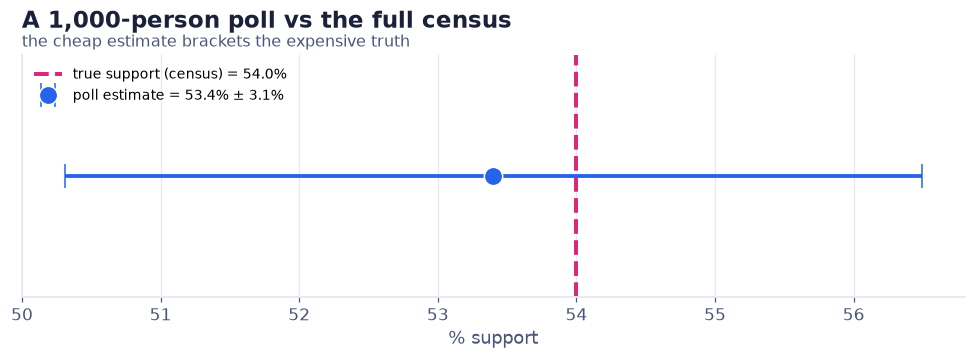

In [6]:
fig, ax = plt.subplots(figsize=(9,3.4))
ax.axvline(p_param*100, color=PINK, lw=2.6, ls="--", label=f"true support (census) = {p_param*100:.1f}%")
ax.errorbar(phat*100, 0, xerr=moe*100, fmt="o", color=BLUE, markersize=12, capsize=8,
            elinewidth=2.5, markeredgecolor="white", label=f"poll estimate = {phat*100:.1f}% ± {moe*100:.1f}%")
titlecard(ax, "A 1,000-person poll vs the full census", "the cheap estimate brackets the expensive truth")
ax.set_xlabel("% support"); ax.set_yticks([]); ax.set_ylim(-1,1); ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

The poll didn't measure everyone — yet it pinned down the true support to within a couple of points. That's the payoff of sampling: **most of the accuracy, a tiny fraction of the cost.**

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li><b>Population</b> = everyone; <b>sample</b> = a slice of them.</li>
<li><b>Parameter</b> (μ, σ, p) describes the population; <b>statistic</b> (x̄, s, p̂) describes the sample.</li>
<li><b>Statistics vary</b> from sample to sample but are <b>unbiased</b> — they center on the parameter.</li>
<li><b>Bigger samples</b> shrink the error (∝ 1/√n).</li>
<li><b>Sampling</b> buys most of a census's accuracy for a fraction of the cost — with a known margin of error.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>